In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

d:\Code\kelompok-7-pba\nlp-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


### Load Data

In [2]:
df = pd.read_csv('../outputs/dataset_preprocessed_razan.csv')

# Encode label
label2id = {'Negative': 0, 'Netral': 1, 'Positive': 2}
id2label = {v: k for k, v in label2id.items()}

df['label'] = df['manual sentiment'].map(label2id)

display(df[['judul', 'manual sentiment', 'label', 'konten_preprocessed']].head(5))

,judul,manual sentiment,label,konten_preprocessed
0,Trump Sebar Exceutive Order: Emang Semengerika...,Positive,2,resmi milik presiden sambut positif agenda pro...
1,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...",Positive,2,nilai tukar rupiah dolar kuat lantik presiden ...
2,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...",Positive,2,pasar uang kuat lantik presiden indeks harga s...
3,"IHSG Merah Lagi, Begini Penjelasan dari Analis...",Negative,0,indeks harga saham gabung ihsg ambruk level pu...
4,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,Positive,2,hargabitcoin btc lewat angka tinggi kisara pic...


In [3]:
df.isnull().sum()

url                    0
judul                  0
konten                 0
manual sentiment       0
konten_preprocessed    0
label                  0
dtype: int64

In [4]:
df['manual sentiment'].value_counts()

manual sentiment
Negative    543
Netral      261
Positive    195
Name: count, dtype: int64

In [5]:
import regex as re

def clean_for_bert(text):
    text = str(text)
    text = re.sub(r'\n+',              ' ', text)   # hapus newline
    text = re.sub(r'\r+',              ' ', text)   # hapus carriage return
    text = re.sub(r'\t+',              ' ', text)   # hapus tab
    text = re.sub(r'([a-z])([A-Z])',   r'\1 \2', text)  # fix merged words
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # hapus URL
    text = re.sub(r'\S+@\S+',          ' ', text)   # hapus email
    text = re.sub(r'[ \t]+',           ' ', text).strip()
    return text

df['konten'] = df['konten'].apply(clean_for_bert)

# Cek hasilnya
df[['konten']].head(5)

,konten
0,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ..."
1,"Jakarta, CNBC Indonesia -Nilai tukar rupiah te..."
2,"Jakarta, CNBC Indonesia-Pasar keuangan Indones..."
3,"Jakarta, CNBC Indonesia -Indeks Harga Saham Ga..."
4,Harga Bitcoin(BTC)pernah melewati angka tertin...


### Train dan Validation Split

In [6]:
# Stratified split untuk menjaga distribusi kelas
X = df['konten']   # pakai konten asli, bukan preprocessed -- IndoBERT sudah handle sendiri
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

df_train = pd.DataFrame({'text': X_train, 'label': y_train}).reset_index(drop=True)
df_val   = pd.DataFrame({'text': X_val,   'label': y_val}).reset_index(drop=True)
df_test  = pd.DataFrame({'text': X_test,  'label': y_test}).reset_index(drop=True)

display(pd.DataFrame({
    'Split'      : ['Train', 'Validation', 'Test'],
    'Count'      : [len(df_train), len(df_val), len(df_test)],
    'Percentage' : [
        f'{len(df_train)/len(df)*100:.1f}%',
        f'{len(df_val)/len(df)*100:.1f}%',
        f'{len(df_test)/len(df)*100:.1f}%'
    ]
}).set_index('Split'))

,Count,Percentage
Split,,
Train,799,80.0%
Validation,100,10.0%
Test,100,10.0%


In [7]:
# Cek distribusi per split
for name, subset in [('Train', df_train), ('Validation', df_val), ('Test', df_test)]:
    counts = subset['label'].map(id2label).value_counts()
    print(f"{name}: {dict(counts)}")

Train: {'Negative': np.int64(434), 'Netral': np.int64(209), 'Positive': np.int64(156)}
Validation: {'Negative': np.int64(55), 'Netral': np.int64(26), 'Positive': np.int64(19)}
Test: {'Negative': np.int64(54), 'Netral': np.int64(26), 'Positive': np.int64(20)}


### Class Weights

In [54]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=df_train['label'].values
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

display(pd.DataFrame({
    'Class'  : ['Negative (0)', 'Neutral (1)', 'Positive (2)'],
    'Weight' : class_weights.round(4)
}))

,Class,Weight
0,Negative (0),0.6137
1,Neutral (1),1.2743
2,Positive (2),1.7073


### Tokenizer & Model

In [55]:
MODEL_NAME = 'indobenchmark/indobert-base-p2'

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size}')

Tokenizer loaded: indobenchmark/indobert-base-p2
Vocab size: 30521


count     799.00
mean      767.44
std       729.79
min        29.00
25%       335.50
50%       504.00
75%       930.50
max      4717.00
Name: Token Length, dtype: float64

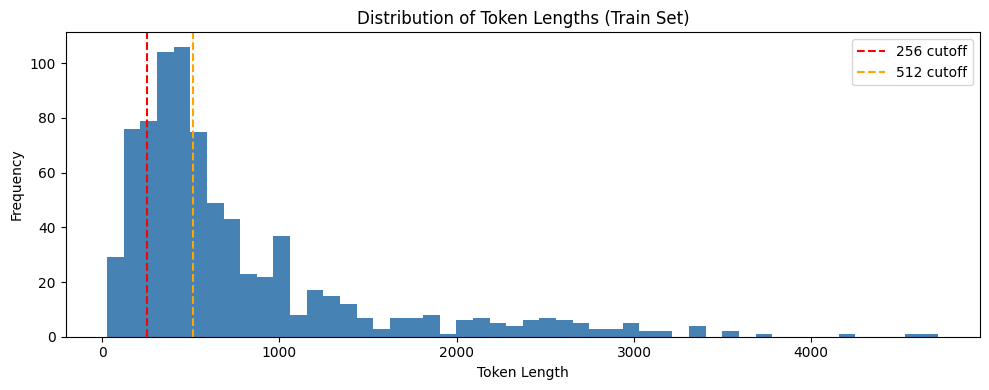

Artikel <= 256 tokens : 18.1%
Artikel <= 512 tokens : 51.2%


In [56]:
# Cek distribusi panjang token untuk menentukan MAX_LEN
token_lengths = df_train['text'].apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True))
)

display(token_lengths.describe().round(2).rename('Token Length'))

plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, color='steelblue', edgecolor='none')
plt.axvline(256, color='red', linestyle='--', label='256 cutoff')
plt.axvline(512, color='orange', linestyle='--', label='512 cutoff')
plt.title('Distribution of Token Lengths (Train Set)')
plt.xlabel('Token Length')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Artikel <= 256 tokens : {(token_lengths <= 256).mean()*100:.1f}%")
print(f"Artikel <= 512 tokens : {(token_lengths <= 512).mean()*100:.1f}%")

In [57]:
# Pilih MAX_LEN berdasarkan distribusi di atas
MAX_LEN   = 128
BATCH_SIZE = 8
EPOCHS     = 10
LR         = 2e-5

### Dataset Class

In [58]:
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts.reset_index(drop=True)
        self.labels    = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length      = self.max_len,
            padding         = 'max_length',
            truncation      = True,
            return_tensors  = 'pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'label'          : torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [59]:
# train_dataset = SentimentDataset(df_train['text'], df_train['label'], tokenizer, MAX_LEN)
# val_dataset   = SentimentDataset(df_val['text'],   df_val['label'],   tokenizer, MAX_LEN)
# test_dataset  = SentimentDataset(df_test['text'],  df_test['label'],  tokenizer, MAX_LEN)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
# test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# print(f'Train batches : {len(train_loader)}')
# print(f'Val batches   : {len(val_loader)}')
# print(f'Test batches  : {len(test_loader)}')

### Random Over Sampling

In [60]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_idx    = df_train.index.values.reshape(-1, 1)
y_train_labels = df_train['label'].values

X_resampled_idx, y_resampled = ros.fit_resample(X_train_idx, y_train_labels)

df_train_ros         = df_train.loc[X_resampled_idx.flatten()].copy()
df_train_ros['label'] = y_resampled
df_train_ros         = df_train_ros.reset_index(drop=True)

# Perbandingan sebelum vs sesudah
before = df_train['label'].map(id2label).value_counts().rename('Before ROS')
after  = pd.Series(y_resampled).map(id2label).value_counts().rename('After ROS')

display(pd.concat([before, after], axis=1))

,Before ROS,After ROS
Negative,434,434
Netral,209,434
Positive,156,434


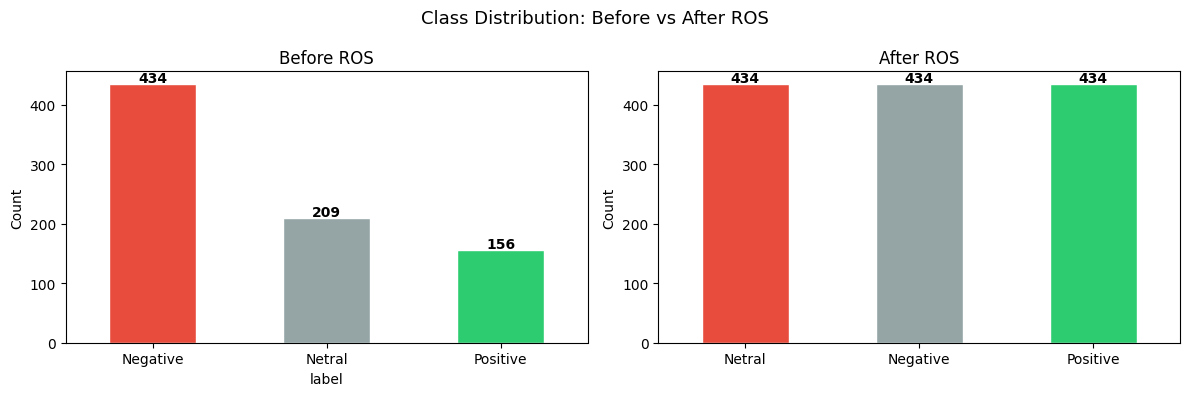

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#95a5a6', '#2ecc71']

before.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white', rot=0)
axes[0].set_title('Before ROS')
axes[0].set_ylabel('Count')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

after.plot(kind='bar', ax=axes[1], color=colors, edgecolor='white', rot=0)
axes[1].set_title('After ROS')
axes[1].set_ylabel('Count')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 3, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution: Before vs After ROS', fontsize=13)
plt.tight_layout()
plt.show()

In [62]:
# Ganti train_dataset pakai df_train_ros
train_dataset = SentimentDataset(df_train_ros['text'], df_train_ros['label'], tokenizer, MAX_LEN)
val_dataset   = SentimentDataset(df_val['text'],       df_val['label'],       tokenizer, MAX_LEN)
test_dataset  = SentimentDataset(df_test['text'],      df_test['label'],      tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train batches (after ROS) : {len(train_loader)}')
print(f'Val batches               : {len(val_loader)}')
print(f'Test batches              : {len(test_loader)}')

Train batches (after ROS) : 163
Val batches               : 13
Test batches              : 13


### Model

In [63]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels  = 3,
    id2label    = id2label,
    label2id    = label2id
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

display(pd.DataFrame([
    {'Info': 'Model',             'Value': MODEL_NAME},
    {'Info': 'Total params',      'Value': f'{total_params:,}'},
    {'Info': 'Trainable params',  'Value': f'{trainable_params:,}'},
    {'Info': 'Device',            'Value': str(device)},
]).set_index('Info'))

[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9404.38it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


,Value
Info,
Model,indobenchmark/indobert-base-p2
Total params,"124,443,651"
Trainable params,"124,443,651"
Device,cuda


### Training Loop

In [64]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super().__init__()
        self.alpha           = alpha
        self.gamma           = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, labels):
        # Label smoothing
        n_classes  = logits.size(1)
        smooth_labels = torch.full_like(logits, self.label_smoothing / (n_classes - 1))
        smooth_labels.scatter_(1, labels.unsqueeze(1), 1.0 - self.label_smoothing)

        log_probs = nn.functional.log_softmax(logits, dim=1)
        ce_loss   = -(smooth_labels * log_probs).sum(dim=1)

        probs   = torch.exp(-ce_loss)
        focal   = (1 - probs) ** self.gamma * ce_loss

        if self.alpha is not None:
            alpha_t = self.alpha[labels]
            focal   = alpha_t * focal

        return focal.mean()

criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0, label_smoothing=0.1)

In [65]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(0.1 * total_steps)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps
)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

display(pd.DataFrame([
    {'Info': 'Total training steps', 'Value': total_steps},
    {'Info': 'Warmup steps',         'Value': warmup_steps},
    {'Info': 'Learning rate',        'Value': LR},
    {'Info': 'Epochs',               'Value': EPOCHS},
]).set_index('Info'))

,Value
Info,
Total training steps,1630.00000
Warmup steps,163.00000
Learning rate,0.00002
Epochs,10.00000


In [66]:
def train_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion(outputs.logits, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds       = outputs.logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss    = criterion(outputs.logits, labels)

            total_loss += loss.item()
            preds       = outputs.logits.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [67]:
# history        = []
# best_val_f1    = 0
# best_model_path = '../outputs/best_model.pt'
# patience       = 3  # stop kalau tidak improve 3 epoch berturut
# no_improve     = 0

# for epoch in range(1, EPOCHS + 1):
#     train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
#     val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)

#     val_f1 = f1_score(val_labels, val_preds, average='macro')

#     history.append({
#         'epoch'      : epoch,
#         'train_loss' : round(train_loss, 4),
#         'val_loss'   : round(val_loss, 4),
#         'train_acc'  : round(train_acc, 4),
#         'val_acc'    : round(val_acc, 4),
#         'val_f1'     : round(val_f1, 4),
#     })

#     print(f"Epoch {epoch}/{EPOCHS} | "
#           f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
#           f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} F1: {val_f1:.4f}")

#     if val_f1 > best_val_f1:
#         best_val_f1 = val_f1
#         no_improve  = 0
#         torch.save(model.state_dict(), best_model_path)
#         print(f"  --> Best model saved (val_f1: {val_f1:.4f})")
#     else:
#         no_improve += 1
#         print(f"  --> No improvement ({no_improve}/{patience})")
#         if no_improve >= patience:
#             print("Early stopping triggered.")
#             break

In [68]:
# Eksperimen gamma -- jalankan training ulang untuk masing-masing
# Mulai dari gamma=2.0, kalau Neutral masih jelek naikkan ke 3.0 lalu 5.0
# Makin tinggi gamma, makin fokus model ke sampel yang susah (Neutral)

for gamma in [2.0, 3.0, 5.0]:
    print(f"\n{'='*40}")
    print(f"Testing gamma = {gamma}")
    print(f"{'='*40}")

    criterion = FocalLoss(alpha=class_weights_tensor, gamma=gamma, label_smoothing=0.1)

    # Reset model setiap eksperimen
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=3, id2label=id2label, label2id=label2id
    ).to(device)

    optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = warmup_steps,
        num_training_steps = total_steps
    )

    best_val_f1 = 0
    no_improve  = 0
    patience    = 3

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, criterion, device)
        val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, criterion, device)
        val_f1 = f1_score(val_labels, val_preds, average='macro')

        print(f"Epoch {epoch} | Train Loss: {train_loss:.4f} | Val F1: {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            no_improve  = 0
            torch.save(model.state_dict(), f'../outputs/best_model_gamma{gamma}.pt')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # Eval test set
    model.load_state_dict(torch.load(f'../outputs/best_model_gamma{gamma}.pt', map_location=device))
    _, _, test_preds, test_labels_out = eval_epoch(model, test_loader, criterion, device)

    print(f"\nGamma {gamma} -- Test Results:")
    print(classification_report(test_labels_out, test_preds, target_names=['Negative', 'Netral', 'Positive']))


Testing gamma = 2.0


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7055.03it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 | Train Loss: 0.5069 | Val F1: 0.5160
Epoch 2 | Train Loss: 0.2942 | Val F1: 0.5269
Epoch 3 | Train Loss: 0.1331 | Val F1: 0.5734
Epoch 4 | Train Loss: 0.0763 | Val F1: 0.5773
Epoch 5 | Train Loss: 0.0577 | Val F1: 0.5641
Epoch 6 | Train Loss: 0.0515 | Val F1: 0.5697
Epoch 7 | Train Loss: 0.0510 | Val F1: 0.5914
Epoch 8 | Train Loss: 0.0508 | Val F1: 0.5701
Epoch 9 | Train Loss: 0.0508 | Val F1: 0.5701
Epoch 10 | Train Loss: 0.0507 | Val F1: 0.5956

Gamma 2.0 -- Test Results:
              precision    recall  f1-score   support

    Negative       0.73      0.81      0.77        54
      Netral       0.41      0.27      0.33        26
    Positive       0.57      0.65      0.60        20

    accuracy                           0.64       100
   macro avg       0.57      0.58      0.57       100
weighted avg       0.62      0.64      0.62       100


Testing gamma = 3.0


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 3102.72it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 | Train Loss: 0.3351 | Val F1: 0.4781
Epoch 2 | Train Loss: 0.1804 | Val F1: 0.5449
Epoch 3 | Train Loss: 0.0809 | Val F1: 0.5693
Epoch 4 | Train Loss: 0.0327 | Val F1: 0.5941
Epoch 5 | Train Loss: 0.0196 | Val F1: 0.5952
Epoch 6 | Train Loss: 0.0175 | Val F1: 0.5886
Epoch 7 | Train Loss: 0.0168 | Val F1: 0.5985
Epoch 8 | Train Loss: 0.0168 | Val F1: 0.6006
Epoch 9 | Train Loss: 0.0167 | Val F1: 0.6006
Epoch 10 | Train Loss: 0.0167 | Val F1: 0.6006

Gamma 3.0 -- Test Results:
              precision    recall  f1-score   support

    Negative       0.74      0.83      0.78        54
      Netral       0.44      0.31      0.36        26
    Positive       0.67      0.70      0.68        20

    accuracy                           0.67       100
   macro avg       0.62      0.61      0.61       100
weighted avg       0.65      0.67      0.65       100


Testing gamma = 5.0


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2551.69it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p2
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 | Train Loss: 0.1569 | Val F1: 0.2802
Epoch 2 | Train Loss: 0.0908 | Val F1: 0.5544
Epoch 3 | Train Loss: 0.0321 | Val F1: 0.6070
Epoch 4 | Train Loss: 0.0110 | Val F1: 0.6110
Epoch 5 | Train Loss: 0.0031 | Val F1: 0.5631
Epoch 6 | Train Loss: 0.0023 | Val F1: 0.6157
Epoch 7 | Train Loss: 0.0021 | Val F1: 0.6053
Epoch 8 | Train Loss: 0.0020 | Val F1: 0.6401
Epoch 9 | Train Loss: 0.0019 | Val F1: 0.6053
Epoch 10 | Train Loss: 0.0019 | Val F1: 0.6053

Gamma 5.0 -- Test Results:
              precision    recall  f1-score   support

    Negative       0.68      0.76      0.72        54
      Netral       0.29      0.15      0.20        26
    Positive       0.50      0.65      0.57        20

    accuracy                           0.58       100
   macro avg       0.49      0.52      0.49       100
weighted avg       0.54      0.58      0.55       100



### Training Curves

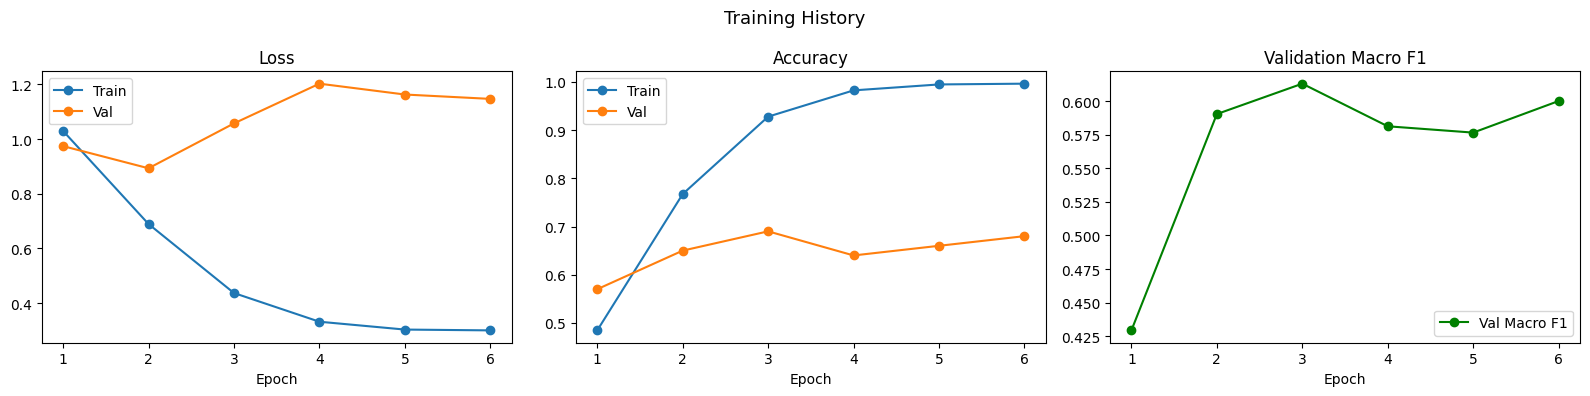

In [74]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train', marker='o')
axes[0].plot(history_df['epoch'], history_df['val_loss'],   label='Val',   marker='o')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_acc'], label='Train', marker='o')
axes[1].plot(history_df['epoch'], history_df['val_acc'],   label='Val',   marker='o')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_f1'], label='Val Macro F1', marker='o', color='green')
axes[2].set_title('Validation Macro F1')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.suptitle('Training History', fontsize=13)
plt.tight_layout()
plt.show()

### Test set evaluation

In [75]:
# Load best model
model.load_state_dict(torch.load(best_model_path, map_location=device))

_, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, criterion, device)

print(classification_report(
    test_labels, test_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

              precision    recall  f1-score   support

    Negative       0.70      0.83      0.76        54
     Neutral       0.36      0.19      0.25        26
    Positive       0.59      0.65      0.62        20

    accuracy                           0.63       100
   macro avg       0.55      0.56      0.54       100
weighted avg       0.59      0.63      0.60       100



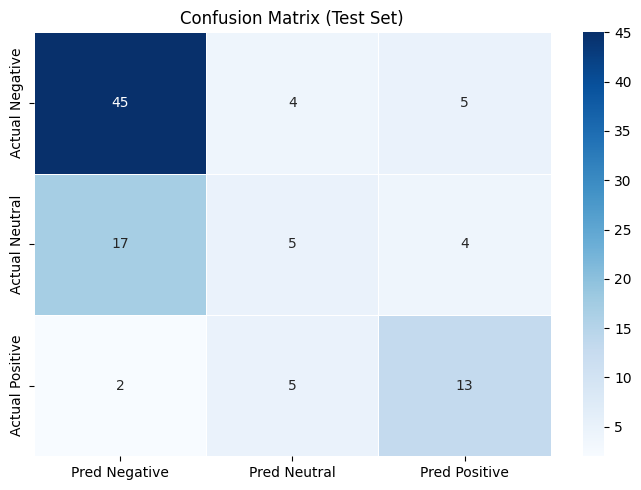

In [76]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
cm_df = pd.DataFrame(
    cm,
    index   = ['Actual Negative', 'Actual Neutral', 'Actual Positive'],
    columns = ['Pred Negative',   'Pred Neutral',   'Pred Positive']
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax, linewidths=0.5)
ax.set_title('Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

In [72]:
# Ringkasan metrik
display(pd.DataFrame([
    {'Metric': 'Accuracy',        'Value': round(accuracy_score(test_labels, test_preds), 4)},
    {'Metric': 'Precision',       'Value': round(precision_score(test_labels, test_preds, average='macro'), 4)},
    {'Metric': 'Recall',          'Value': round(recall_score(test_labels, test_preds, average='macro'), 4)},
    {'Metric': 'Macro F1',        'Value': round(f1_score(test_labels, test_preds, average='macro'), 4)},
    {'Metric': 'Weighted F1',     'Value': round(f1_score(test_labels, test_preds, average='weighted'), 4)},
]).set_index('Metric'))

,Value
Metric,
Accuracy,0.6300
Precision,0.5504
Recall,0.5585
Macro F1,0.5439
Weighted F1,0.6007


In [73]:
# Lihat artikel Neutral yang diprediksi Negative
val_df_check = df_test.copy()
val_df_check['pred'] = test_preds
val_df_check['actual'] = test_labels

neutral_as_neg = val_df_check[
    (val_df_check['actual'] == 1) &  # Neutral
    (val_df_check['pred']   == 0)    # diprediksi Negative
]

display(neutral_as_neg[['text', 'actual', 'pred']].assign(
    text=lambda x: x['text'].str[:300]
))

,text,actual,pred
2,Presiden Amerika Serikat (AS) Donald Trump men...,1,0
4,Amerika Serikat (AS) menerapkan kebijakantarif...,1,0
13,"Setelah Inggris, Cina telah mencapai kesepakat...",1,0
17,Desisan dan semburan udara bertekanan membentu...,1,0
30,"Bloomberg Technoz, Jakarta- Menteri Koordinato...",1,0
33,"Jakarta, CNBC Indonesia- Presiden Finlandia Al...",1,0
38,"TEMPO.CO,Jakarta- Amerika Serikat telah meneke...",1,0
39,Ditas Lopez dan Neil Jerome Morales - Bloomber...,1,0
44,Jakarta: Ketegangan terkait perang dagang anta...,1,0
47,"Jakarta, CNBC Indonesia- Hubungan yang sempat ...",1,0
